In [142]:
import tensorflow as tf 
import numpy as np 
import pandas as pd 
import matplotlib.pyplot as plt 
from sklearn.model_selection import train_test_split
from tensorflow.keras.preprocessing.text import Tokenizer
from tensorflow.keras.preprocessing.sequence import pad_sequences
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Embedding, GlobalAveragePooling1D, Dense

In [143]:
data = pd.read_csv(r"F:\GitHub\Machine Learning\ML DL Frameworks\Tensorflow\Day 01\SPAM text message 20170820 - Data.csv")

In [144]:
data.head(10)

,Category,Message
0,ham,"Go until jurong point, crazy.. Available only ..."
1,ham,Ok lar... Joking wif u oni...
2,spam,Free entry in 2 a wkly comp to win FA Cup fina...
3,ham,U dun say so early hor... U c already then say...
4,ham,"Nah I don't think he goes to usf, he lives aro..."
5,spam,FreeMsg Hey there darling it's been 3 week's n...
6,ham,Even my brother is not like to speak with me. ...
7,ham,As per your request 'Melle Melle (Oru Minnamin...
8,spam,WINNER!! As a valued network customer you have...
9,spam,Had your mobile 11 months or more? U R entitle...


In [145]:
data.groupby('Category').describe().T

Category                           ham  \
Message count                     4825   
        unique                    4516   
        top     Sorry, I'll call later   
        freq                        30   

Category                                                     spam  
Message count                                                 747  
        unique                                                641  
        top     Please call our customer service representativ...  
        freq                                                    4

<Axes: xlabel='count', ylabel='Category'>

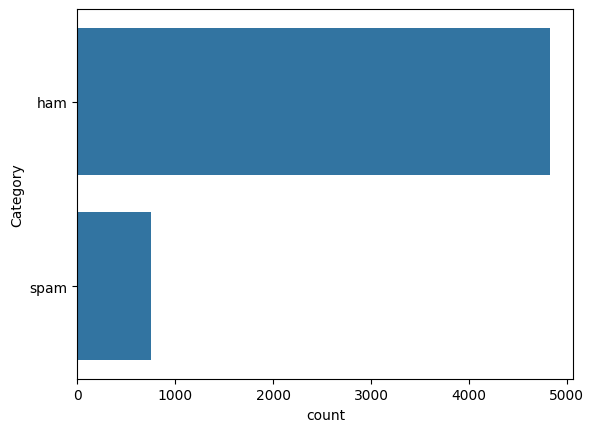

In [146]:
import seaborn as sns 
plt.figure()
sns.countplot(data['Category'])

In [147]:
ham_msg = data[data['Category'] == 'ham']
spam_msg = data[data['Category'] == 'spam']

In [148]:
ham_len = len(ham_msg)
spam_len = len(spam_msg)
min_data_size = min(ham_len, spam_len)
spam_len, ham_len, min_data_size

(747, 4825, 747)

In [149]:
# downsample because the dataset size is not equal
ham_msg = ham_msg.sample(n=min_data_size, random_state=42)
spam_msg = spam_msg.sample(n=min_data_size, random_state=42)
len(ham_msg), len(spam_msg)

(747, 747)

In [150]:
balanced_data = pd.concat([ham_msg, spam_msg]).reset_index(drop=True)

<Axes: xlabel='count', ylabel='Category'>

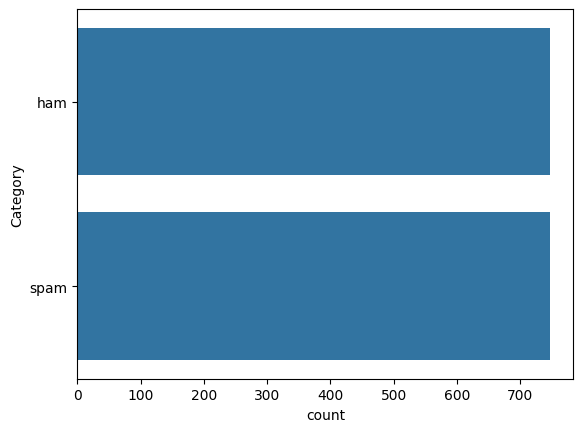

In [151]:
plt.figure()
sns.countplot(balanced_data["Category"])

In [152]:
balanced_data["label"] = balanced_data["Category"].map({"ham": 0, "spam": 1})

In [153]:
balanced_data

,Category,Message,label
0,ham,If i not meeting ü all rite then i'll go home ...,0
1,ham,"I.ll always be there, even if its just in spir...",0
2,ham,"Sorry that took so long, omw now",0
3,ham,I thk 50 shd be ok he said plus minus 10.. Did...,0
4,ham,Dunno i juz askin cos i got a card got 20% off...,0
...,...,...,...
1489,spam,#ERROR!,1
1490,spam,Hi. Customer Loyalty Offer:The NEW Nokia6650 M...,1
1491,spam,Call from 08702490080 - tells u 2 call 0906635...,1
1492,spam,Ur cash-balance is currently 500 pounds - to m...,1


In [154]:
train_msg, test_msg, train_labels, test_labels = train_test_split(
    balanced_data["Message"], balanced_data["label"], test_size=0.2, random_state=42
)

In [155]:
vocab_size = 500
unknown_token = "<OOV>"
max_len = 50

In [156]:
token = Tokenizer(num_words=vocab_size, oov_token=unknown_token)
token.fit_on_texts(train_msg)

In [157]:
word_index = token.word_index
word_index

{'<OOV>': 1,
 'to': 2,
 'you': 3,
 'a': 4,
 'i': 5,
 'call': 6,
 'the': 7,
 'your': 8,
 'u': 9,
 'is': 10,
 'for': 11,
 'and': 12,
 'now': 13,
 'or': 14,
 '2': 15,
 'free': 16,
 'in': 17,
 'on': 18,
 'have': 19,
 'ur': 20,
 'of': 21,
 '4': 22,
 'from': 23,
 'txt': 24,
 'are': 25,
 'with': 26,
 'text': 27,
 'me': 28,
 'this': 29,
 'mobile': 30,
 'stop': 31,
 'my': 32,
 'no': 33,
 'get': 34,
 'will': 35,
 'just': 36,
 'claim': 37,
 'reply': 38,
 'be': 39,
 'only': 40,
 'that': 41,
 'www': 42,
 'it': 43,
 'prize': 44,
 'send': 45,
 'new': 46,
 'we': 47,
 'our': 48,
 'not': 49,
 'at': 50,
 'out': 51,
 'so': 52,
 'cash': 53,
 'can': 54,
 'all': 55,
 'do': 56,
 '1': 57,
 'won': 58,
 'if': 59,
 "i'm": 60,
 '150p': 61,
 'win': 62,
 'uk': 63,
 'go': 64,
 'please': 65,
 'nokia': 66,
 'but': 67,
 'urgent': 68,
 'who': 69,
 't': 70,
 'when': 71,
 'contact': 72,
 'co': 73,
 'know': 74,
 'by': 75,
 'been': 76,
 '50': 77,
 'what': 78,
 'msg': 79,
 'up': 80,
 'lt': 81,
 'day': 82,
 'week': 83,
 'tone'

In [158]:
train_sequences = token.texts_to_sequences(train_msg)
test_sequences = token.texts_to_sequences(test_msg)

In [159]:
train_padded = pad_sequences(
    train_sequences, maxlen=max_len, padding="post", truncating="post"
)
test_padded = pad_sequences(
    test_sequences, maxlen=max_len, padding="post", truncating="post"
)

In [160]:
print("Original message:", train_msg.iloc[0])
print("Padded sequence:", train_padded[0])

Original message: I wanted to ask ü to wait 4 me to finish lect. Cos my lect finishes in an hour anyway.
Padded sequence: [  5   1   2 281 114   2   1  22  28   2   1   1 307  32   1   1  17 172
 452   1   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0   0
   0   0   0   0   0   0   0   0   0   0   0   0   0   0]


In [161]:
model = Sequential(
    [
        Embedding(input_dim=vocab_size, output_dim=16, input_length=max_len),
        GlobalAveragePooling1D(),
        Dense(16, activation="relu"),
        Dense(1, activation="sigmoid"),
    ]
)

f:\GitHub\Machine Learning\ML DL Frameworks\Tensorflow\venv\Lib\site-packages\keras\src\layers\core\embedding.py:100: UserWarning: Argument `input_length` is deprecated. Just remove it.
  warnings.warn(


In [162]:
model.compile(loss="binary_crossentropy", optimizer="adam", metrics=["accuracy"])

In [163]:
epoch = 30
early_stop = tf.keras.callbacks.EarlyStopping(monitor="val_loss", patience=3)
history = model.fit(
    train_padded,
    train_labels,
    epochs=epoch,
    validation_data=(test_padded, test_labels),
    callbacks=[early_stop],
)

Epoch 1/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 1s 6ms/step - accuracy: 0.5029 - loss: 0.6728 - val_accuracy: 0.5151 - val_loss: 0.6511
Epoch 2/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.6544 - loss: 0.6159 - val_accuracy: 0.7993 - val_loss: 0.5706
Epoch 3/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8059 - loss: 0.5324 - val_accuracy: 0.8328 - val_loss: 0.4844
Epoch 4/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8444 - loss: 0.4526 - val_accuracy: 0.8395 - val_loss: 0.4121
Epoch 5/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.8653 - loss: 0.3899 - val_accuracy: 0.8528 - val_loss: 0.3619
Epoch 6/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8728 - loss: 0.3400 - val_accuracy: 0.8662 - val_loss: 0.3137
Epoch 7/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.8954 - loss: 0.2951 - val_accuracy: 0.8963 - val_loss: 0.2719
Epoch 8/30
38/38 ━━━━━━━━━━━━━━━━━━━━ 0s 2ms/step - accuracy: 0.9146 - loss: 0.2553 - val_accuracy: 0.9164 - val_loss:

In [164]:
model.evaluate(test_padded, test_labels)

10/10 ━━━━━━━━━━━━━━━━━━━━ 0s 3ms/step - accuracy: 0.9666 - loss: 0.1112 


[0.11124978959560394, 0.9665551781654358]

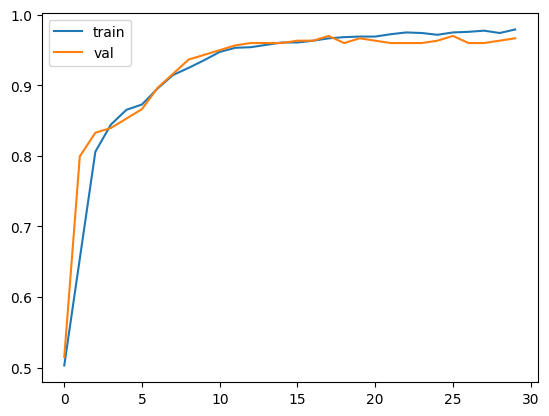

In [ ]:
plt.plot(history.history["accuracy"], label="train")
plt.plot(history.history["val_accuracy"], label="val")
plt.legend()
plt.show()z``